In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import pandas as pd
import pandas as pd
import scvi
# Load a sample dataset
mdata = pt.dt.papalexi_2021()



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/s

In [2]:
adata=mdata["rna"]


In [3]:
mdata

MuData object with n_obs × n_vars = 20729 × 18776
  4 modalities
    rna:	20729 x 18649
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    adt:	20729 x 4
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    hto:	20729 x 12
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'
    gdo:	20729 x 111
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
      var:	'name'

In [4]:
mdata.mod["gdo"]

AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_GDO', 'nCount_ADT', 'nFeature_ADT', 'percent.mito', 'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'Phase'
    var: 'name'

In [5]:
gdo = mdata.mod["gdo"]

# Extract the guide count matrix
gdo.X
print(gdo.X)

  (0, 0)	1.0
  (1, 0)	1.0
  (2, 0)	1.0
  (3, 0)	1.0
  (4, 0)	1.0
  (5, 0)	1.0
  (6, 0)	1.0
  (7, 0)	1.0
  (8, 0)	1.0
  (9, 0)	1.0
  (10, 0)	1.0
  (11, 0)	1.0
  (12, 0)	1.0
  (13, 0)	1.0
  (14, 0)	1.0
  (15, 0)	1.0
  (16, 0)	1.0
  (17, 0)	1.0
  (18, 0)	1.0
  (19, 0)	1.0
  (20, 0)	1.0
  (21, 0)	1.0
  (22, 0)	1.0
  (23, 0)	1.0
  (24, 0)	1.0
  :	:
  (20704, 110)	1.0
  (20705, 110)	1.0
  (20706, 110)	1.0
  (20707, 110)	1.0
  (20708, 110)	1.0
  (20709, 110)	1.0
  (20710, 110)	1.0
  (20711, 110)	1.0
  (20712, 110)	1.0
  (20713, 110)	1.0
  (20714, 110)	1.0
  (20715, 110)	1.0
  (20716, 110)	1.0
  (20717, 110)	1.0
  (20718, 110)	1.0
  (20719, 110)	1.0
  (20720, 110)	1.0
  (20721, 110)	1.0
  (20722, 110)	34.0
  (20723, 110)	1.0
  (20724, 110)	1.0
  (20725, 110)	1.0
  (20726, 110)	1.0
  (20727, 110)	1.0
  (20728, 110)	1.0


In [6]:
gdo = mdata.mod["gdo"]

# Extract the guide count matrix
guide_count_matrix = gdo.X


guide_count_df = pd.DataFrame(guide_count_matrix.toarray(), index=gdo.obs.index, columns=gdo.var.index)

print(guide_count_df)

index                eGFPg1  CUL3g1  CUL3g2  CUL3g3  CMTM6g1  CMTM6g2  \
index                                                                   
l1_AAACCTGAGCCAGAAC     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGAGTGGACGT     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGCATGAGCGA     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACCTGTCTTGTCAT     1.0     1.0     1.0     1.0      1.0      1.0   
l1_AAACGGGAGAACAACT     1.0     1.0     1.0     1.0      1.0      1.0   
...                     ...     ...     ...     ...      ...      ...   
l8_TTTGTCAGTCACTTCC     1.0     1.0     1.0     1.0    177.0      2.0   
l8_TTTGTCAGTGACGGTA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCAGTTCCACAA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCATCACGCATA     1.0     1.0     1.0     1.0      1.0      1.0   
l8_TTTGTCATCTGTACGA     1.0     1.0     1.0     1.0      1.0      1.0   

index                CMTM6g3  NTg1  NTg2  NTg3  ..

In [14]:
guide_adata = sc.AnnData(X=guide_count_df.values)
guide_adata.obs.index = guide_count_df.index
guide_adata.var.index = guide_count_df.columns
guide_adata.obs['replicate'] = mdata["rna"].obs['replicate']
guide_adata.obs['Phase'] = mdata["rna"].obs['Phase']
guide_adata.obs['perturbation'] = mdata["rna"].obs['perturbation']
# Inspect the AnnData object
print(guide_adata)

AnnData object with n_obs × n_vars = 20729 × 111
    obs: 'replicate', 'Phase', 'perturbation'


In [15]:
scvi.model.SCVI.setup_anndata(guide_adata)


In [16]:
scvi_ref = scvi.model.SCVI(
    guide_adata,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train(accelerator='gpu')

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 386/386: 100%|███████████████████████████████████████████| 386/386 [06:54<00:00,  1.63it/s, v_num=1, train_loss_step=146, train_loss_epoch=146]

`Trainer.fit` stopped: `max_epochs=386` reached.


Epoch 386/386: 100%|███████████████████████████████████████████| 386/386 [06:54<00:00,  1.07s/it, v_num=1, train_loss_step=146, train_loss_epoch=146]


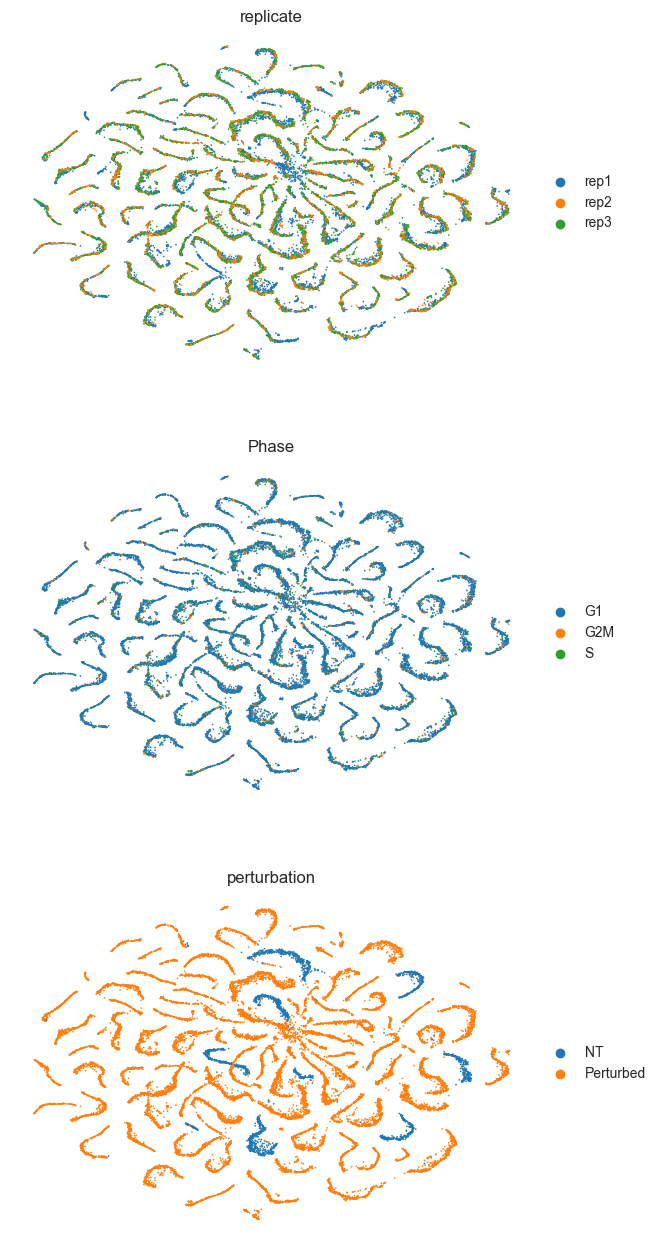

In [17]:
SCVI_LATENT_KEY = "X_scVI"

guide_adata.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(guide_adata, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(guide_adata)
sc.tl.umap(guide_adata)
sc.pl.umap(
    guide_adata,
    color=["replicate", "Phase", "perturbation"],
    frameon=False,
    ncols=1,
)

In [18]:
guide_adata.obs

,replicate,Phase,perturbation,_scvi_batch,_scvi_labels,leiden
index,,,,,,
l1_AAACCTGAGCCAGAAC,rep1,G1,Perturbed,0,0,26
l1_AAACCTGAGTGGACGT,rep1,G1,Perturbed,0,0,70
l1_AAACCTGCATGAGCGA,rep1,G1,Perturbed,0,0,79
l1_AAACCTGTCTTGTCAT,rep1,G1,Perturbed,0,0,6
l1_AAACGGGAGAACAACT,rep1,G1,Perturbed,0,0,60
...,...,...,...,...,...,...
l8_TTTGTCAGTCACTTCC,rep3,G1,Perturbed,0,0,35
l8_TTTGTCAGTGACGGTA,rep2,G1,NT,0,0,3
l8_TTTGTCAGTTCCACAA,rep3,G1,Perturbed,0,0,1
